# Credit Risk Modeling: Champion vs Challengers

**Authors:** Illian Hashatel, Reda Allab, Issa Ali Adoum  
**Supervisor:** Bertrand Hassani  
**Course:** Data Science Software, M2 IRFA, Université Paris 1

---

This notebook reproduces the full analysis presented in our report: construction of a binary classification model to predict credit default on a dataset of 32,581 observations.

**Outline**
1. Preprocessing (cleaning, imputation, encoding)
2. Champion model: Logistic Regression (L1 / L2 / Elastic Net)
3. Challenger 1: Random Forest
4. Challenger 2: XGBoost
5. Challenger 3: Neural Network (MLP)
6. Correlation structure analysis
7. Final model comparison (F2-score)

## 1. Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay, fbeta_score
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

## 2. Preprocessing

### 2.1 Loading and cleaning

We start by loading the dataset, creating missingness indicator variables (so that models can exploit the information carried by missing data), then removing observations with clearly unrealistic values (age above 100, employment length above 60 years).

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')

print(f'Initial shape: {df.shape}')
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\nTarget distribution:\n{df["loan_status"].value_counts(normalize=True).round(3)}')

Initial shape: (32581, 12)

Missing values:
person_emp_length     895
loan_int_rate        3116
dtype: int64

Target distribution:
loan_status
0    0.782
1    0.218
Name: proportion, dtype: float64


In [3]:
# Missingness indicators -- created BEFORE imputation to preserve the information
df['is_missing_rate']      = df['loan_int_rate'].isna().astype(int)
df['is_missing_emplength'] = df['person_emp_length'].isna().astype(int)

# Remove unrealistic outliers
df = df[
    (df['person_age'] < 100) &
    ((df['person_emp_length'] < 60) | (df['person_emp_length'].isna()))
].copy()

# Median imputation (robust to skewed distributions)
df['loan_int_rate']     = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

print(f'Shape after cleaning: {df.shape}')

Shape after cleaning: (32574, 14)


### 2.2 Encoding categorical variables

- `cb_person_default_on_file`: binary Y/N mapped to 1/0  
- `loan_grade`: ordinal (A < B < ... < G), ordinal encoding 1 to 7  
- `person_home_ownership`, `loan_intent`: nominal, one-hot encoding

In [4]:
# Binary variable
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

# Ordinal variable
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['loan_grade'] = df['loan_grade'].map(grade_map)

# Nominal variables -- one-hot (drop_first to avoid perfect multicollinearity)
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

# Features / target split
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Stratified train/test split (80/20) -- stratification preserves the default ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features: {list(X.columns)}')

X_train: (26059, 19) | X_test: (6515, 19)
Features: ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'is_missing_rate', 'is_missing_emplength', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


## 3. Champion Model: Logistic Regression

Logistic regression is chosen as the champion model for its native interpretability (coefficients are directly readable as log-odds) and its compatibility with regulatory requirements (GDPR, Basel III).

We compare three regularization schemes: L1 (Lasso), L2 (Ridge) and Elastic Net, tuning hyperparameters by optimizing the ROC-AUC through stratified 5-fold cross-validation. The `class_weight='balanced'` parameter compensates for the class imbalance (~22% defaults).

In [5]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- L1 (Lasso) ---
pipeline_l1 = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='l1', solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_STATE, max_iter=1000
    ))
])
grid_l1 = GridSearchCV(
    pipeline_l1, {'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_l1.fit(X_train, y_train)

# --- L2 (Ridge) ---
pipeline_l2 = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='l2', solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_STATE, max_iter=1000
    ))
])
grid_l2 = GridSearchCV(
    pipeline_l2, {'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_l2.fit(X_train, y_train)

# --- Elastic Net ---
pipeline_en = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='elasticnet', solver='saga',
        class_weight='balanced',
        random_state=RANDOM_STATE, max_iter=1000
    ))
])
grid_en = GridSearchCV(
    pipeline_en,
    {'classifier__C': [0.001, 0.01, 0.1, 1, 10], 'classifier__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
    cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_en.fit(X_train, y_train)

# Retrieve probabilities and predictions (default threshold 0.5)
y_pred_proba_l1 = grid_l1.predict_proba(X_test)[:, 1]
y_pred_proba_l2 = grid_l2.predict_proba(X_test)[:, 1]
y_pred_proba_en = grid_en.predict_proba(X_test)[:, 1]

y_pred_l1 = grid_l1.predict(X_test)
y_pred_l2 = grid_l2.predict(X_test)
y_pred_en = grid_en.predict(X_test)

coef_l1 = grid_l1.best_estimator_.named_steps['classifier'].coef_[0]
coef_l2 = grid_l2.best_estimator_.named_steps['classifier'].coef_[0]
coef_en = grid_en.best_estimator_.named_steps['classifier'].coef_[0]

# Summary table
results_lr = pd.DataFrame({
    'Regularization'    : ['L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net'],
    'ROC-AUC (CV)'      : [grid_l1.best_score_, grid_l2.best_score_, grid_en.best_score_],
    'ROC-AUC (Test)'    : [
        roc_auc_score(y_test, y_pred_proba_l1),
        roc_auc_score(y_test, y_pred_proba_l2),
        roc_auc_score(y_test, y_pred_proba_en),
    ],
    'Best C'            : [
        grid_l1.best_params_['classifier__C'],
        grid_l2.best_params_['classifier__C'],
        grid_en.best_params_['classifier__C'],
    ],
    'Non-zero coef.'    : [
        int(np.sum(coef_l1 != 0)),
        len(coef_l2),
        int(np.sum(coef_en != 0)),
    ],
})
print(results_lr.to_string(index=False))
print('\nClassification report (L1 retained):')
print(classification_report(y_test, y_pred_l1))

Regularization  ROC-AUC (CV)  ROC-AUC (Test)  Best C  Non-zero coef.
    L1 (Lasso)      0.866813        0.856989     0.1              19
    L2 (Ridge)      0.866743        0.856856     0.1              19
   Elastic Net      0.866803        0.856978     0.1              19

Classification report (L1 retained):
              precision    recall  f1-score   support

           0       0.92      0.80      0.86      5094
           1       0.52      0.76      0.61      1421

    accuracy                           0.79      6515
   macro avg       0.72      0.78      0.74      6515
weighted avg       0.83      0.79      0.80      6515



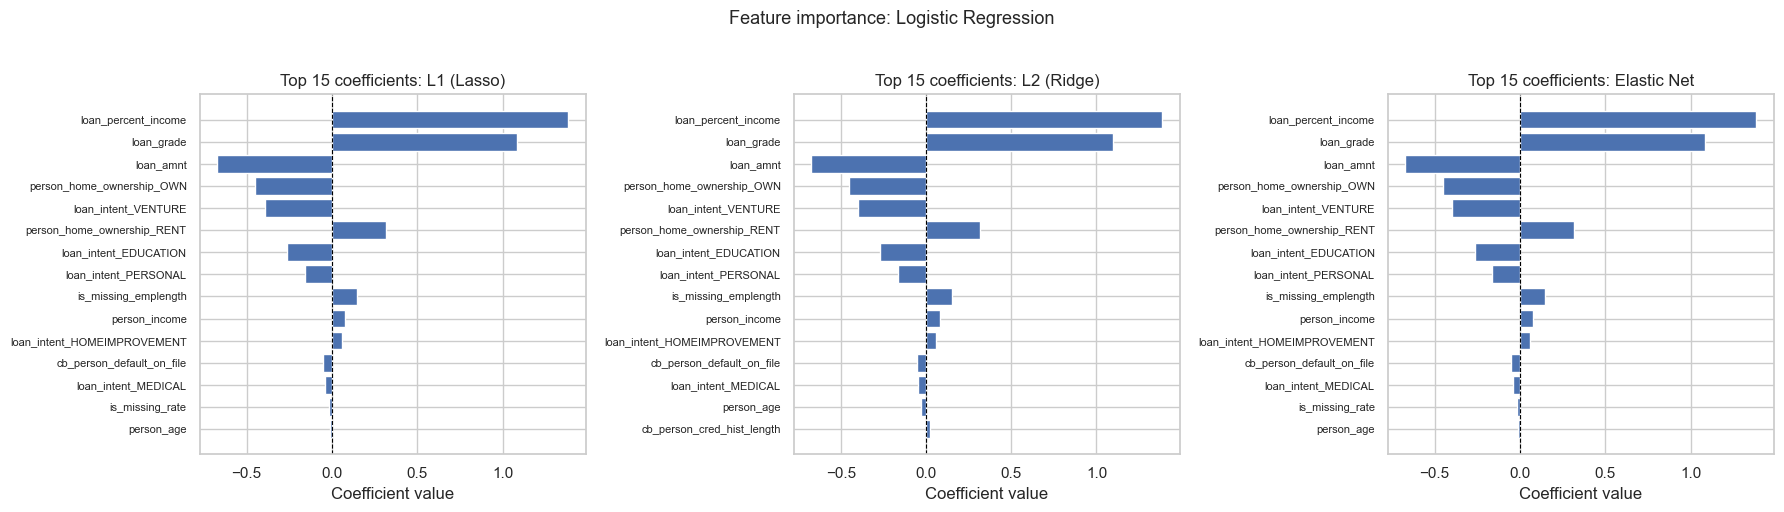

In [6]:
# Coefficient visualization for all three regularization schemes
feature_names = X_train.columns.to_numpy()
models_lr = {'L1 (Lasso)': coef_l1, 'L2 (Ridge)': coef_l2, 'Elastic Net': coef_en}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (name, coef) in zip(axes, models_lr.items()):
    idx = np.argsort(np.abs(coef))[-15:]
    ax.barh(feature_names[idx], coef[idx])
    ax.set_title(f'Top 15 coefficients: {name}')
    ax.set_xlabel('Coefficient value')
    ax.tick_params(axis='y', labelsize=8)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Feature importance: Logistic Regression', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('comparison_regularization_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Challenger 1: Random Forest

Random Forest is an ensemble of independently trained decision trees (bagging). It naturally captures non-linearities and feature interactions while remaining robust to outliers.

We use `class_weight='balanced'` consistently with the logistic regression, so that class imbalance is handled in the same way across all models.

In [7]:
param_grid_rf = {
    'n_estimators'     : [100, 300],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 10],
    'max_features'     : ['sqrt', 'log2'],
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ),
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

rf_best = grid_rf.best_estimator_
print('Best RF hyperparameters:', grid_rf.best_params_)

y_pred_rf  = rf_best.predict(X_test)
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

print(f'ROC-AUC (Test): {roc_auc_score(y_test, y_proba_rf):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
ROC-AUC (Test): 0.9347

Classification report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      5094
           1       0.98      0.71      0.82      1421

    accuracy                           0.93      6515
   macro avg       0.95      0.85      0.89      6515
weighted avg       0.94      0.93      0.93      6515



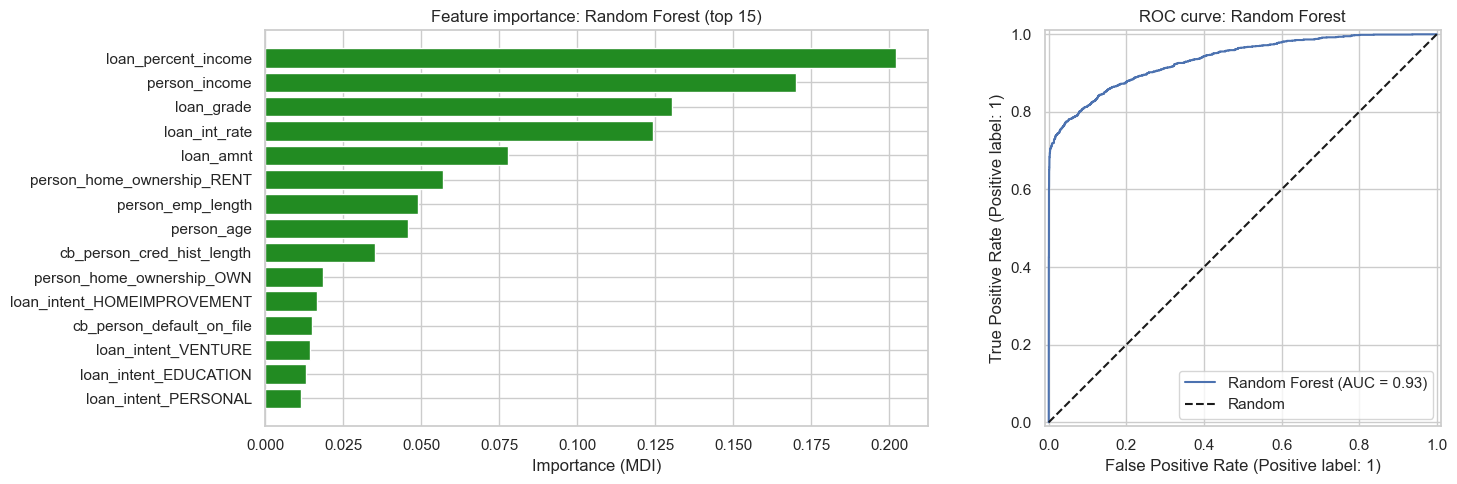

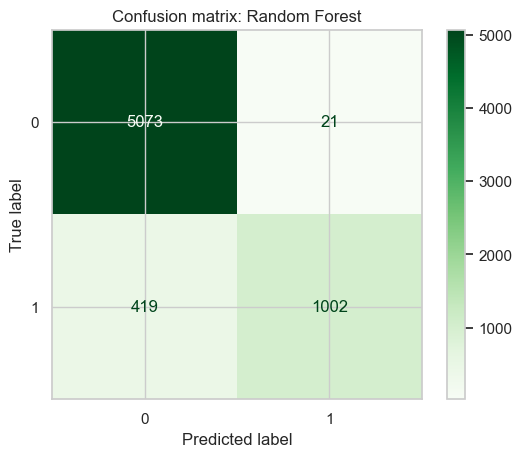

In [8]:
# Feature importance and ROC curve
importances = rf_best.feature_importances_
idx_sorted  = np.argsort(importances)[::-1]
features    = X_train.columns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Feature importance (top 15 for readability)
top15 = idx_sorted[:15]
axes[0].barh(
    [features[i] for i in top15[::-1]],
    importances[top15[::-1]],
    color='forestgreen'
)
axes[0].set_title('Feature importance: Random Forest (top 15)')
axes[0].set_xlabel('Importance (MDI)')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1], name='Random Forest')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_title('ROC curve: Random Forest')
axes[1].legend()

plt.tight_layout()
plt.show()

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Greens')
plt.title('Confusion matrix: Random Forest')
plt.show()

## 5. Challenger 2: XGBoost

XGBoost is a gradient boosting algorithm that builds trees sequentially, each one correcting the errors of the previous one. It is known for strong performance on tabular data and incorporates native regularization (L1/L2 on leaf weights).

To handle class imbalance, we use `scale_pos_weight`, which is the XGBoost equivalent of `class_weight='balanced'`: it is set to the ratio of negative to positive samples.

In [9]:
# Compute the class imbalance ratio
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
print(f'scale_pos_weight = {scale_pos} (negative/positive ratio)')

param_grid_xgb = {
    'n_estimators'    : [100, 500],
    'max_depth'       : [3, 6],
    'learning_rate'   : [0.01, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE
        # no n_jobs here to avoid nested parallelism
    ),
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
print('Best XGB hyperparameters:', grid_xgb.best_params_)

y_pred_xgb  = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print(f'ROC-AUC (CV):   {grid_xgb.best_score_:.4f}')
print(f'ROC-AUC (Test): {roc_auc_score(y_test, y_proba_xgb):.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred_xgb))

scale_pos_weight = 3 (negative/positive ratio)
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best XGB hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'subsample': 1.0}
ROC-AUC (CV):   0.9455
ROC-AUC (Test): 0.9502

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      5094
           1       0.88      0.78      0.83      1421

    accuracy                           0.93      6515
   macro avg       0.91      0.88      0.89      6515
weighted avg       0.93      0.93      0.93      6515



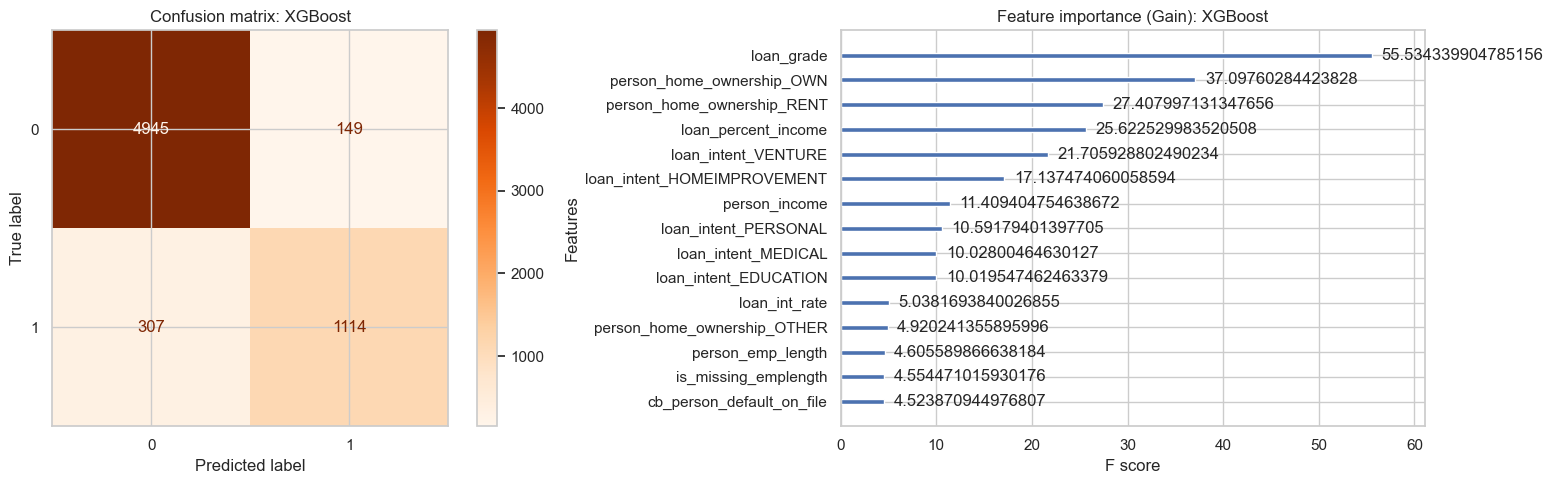

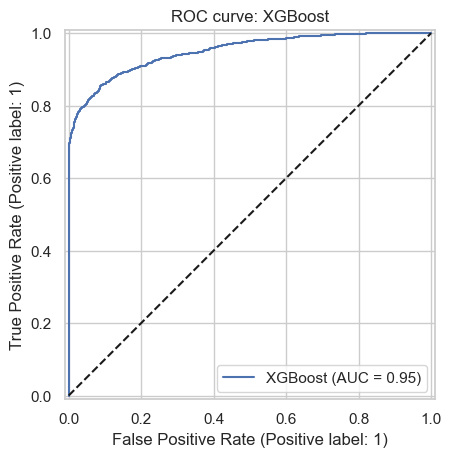

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap='Oranges', ax=axes[0])
axes[0].set_title('Confusion matrix: XGBoost')

# Feature importance (gain)
xgb.plot_importance(
    best_xgb, ax=axes[1], max_num_features=15,
    importance_type='gain', title='Feature importance (Gain): XGBoost'
)
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_xgb, name='XGBoost')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC curve: XGBoost')
plt.show()

## 6. Challenger 3: Neural Network (MLP)

The MLP is the most flexible of the four models: it can capture high-order interactions and highly non-linear decision boundaries. In return, it is less interpretable and more sensitive to hyperparameter choices.

StandardScaler is essential here: gradient descent converges much better when features are standardized.

**Decision threshold optimization**  
Rather than using the default threshold of 0.5, we search for the threshold that maximizes the F2-score on the test set. This is consistent with our asymmetric cost structure (an undetected default costs roughly 6.7 times more than a false positive). The same procedure is then applied to all models to ensure a fair comparison.

In [ ]:
pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    ))
])

param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(64, 32), (128, 64, 32)],
    'mlp__activation'        : ['tanh', 'relu'],
    'mlp__alpha'             : [0.01, 0.05],
}

print('Training MLP (this may take a few minutes)...')
grid_mlp = GridSearchCV(
    pipeline_mlp, param_grid_mlp,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_mlp.fit(X_train, y_train)

best_mlp    = grid_mlp.best_estimator_
y_proba_mlp = best_mlp.predict_proba(X_test)[:, 1]

print(f'Best parameters:  {grid_mlp.best_params_}')
print(f'ROC-AUC (CV):     {grid_mlp.best_score_:.4f}')
print(f'ROC-AUC (Test):   {roc_auc_score(y_test, y_proba_mlp):.4f}')

Training MLP (this may take a few minutes)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [ ]:
# Decision threshold optimization via F2-score
def find_best_f2_threshold(y_true, y_probs, n_thresholds=200):
    """Find the classification threshold that maximizes the F2-score."""
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    scores = [fbeta_score(y_true, (y_probs >= t).astype(int), beta=2) for t in thresholds]
    best_idx = np.argmax(scores)
    return thresholds[best_idx], scores[best_idx]

best_thresh_mlp, best_f2_mlp = find_best_f2_threshold(y_test, y_proba_mlp)
y_pred_mlp = (y_proba_mlp >= best_thresh_mlp).astype(int)

print(f'Optimal threshold: {best_thresh_mlp:.2f}')
print(f'F2-score:          {best_f2_mlp:.3f}')
print('\nClassification report (optimized threshold):')
print(classification_report(y_test, y_pred_mlp))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp, cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion matrix: MLP (threshold={best_thresh_mlp:.2f})')

RocCurveDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[1], name='MLP')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC curve: MLP')

plt.tight_layout()
plt.show()

## 7. Correlation structure analysis

This heatmap is computed on the preprocessed dataframe (after encoding). It helps explain why linear and non-linear models assign different importance to the same features:

- `loan_grade` / `loan_int_rate`: correlation ~0.89. L1 regularization retains one and shrinks the other, while Random Forest distributes importance between both.  
- `person_age` / `cb_person_cred_hist_length`: correlation ~0.88. Including both introduces redundant information that can add noise.  
- XGBoost assigns high importance to `person_home_ownership_RENT`, which acts as a proxy for a risky profile (lower income, less stable employment).

In [ ]:
corr_matrix = X.corr()   # correlation computed on features only

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=.4, annot_kws={'size': 7},
    cbar_kws={'shrink': .8}
)
plt.title('Correlation matrix: preprocessed features', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final comparison: F2-score with threshold optimization

The F2-score is the primary metric for the final comparison. It weights recall four times more than precision, reflecting the asymmetric cost structure of credit scoring:

- **False negative** (undetected default): loss of principal, ~10,000 EUR  
- **False positive** (rejected creditworthy customer): foregone interest, ~1,500 EUR  

For a fair comparison, the same threshold optimization procedure is applied to all four models.

In [ ]:
# Threshold optimization for each model
probas = {
    'Logistic (L1)' : y_pred_proba_l1,
    'Random Forest' : y_proba_rf,
    'XGBoost'       : y_proba_xgb,
    'MLP'           : y_proba_mlp,
}

results_final = []
for name, proba in probas.items():
    thresh, f2 = find_best_f2_threshold(y_test, proba)
    y_pred_opt = (proba >= thresh).astype(int)
    results_final.append({
        'Model'          : name,
        'ROC-AUC (Test)' : round(roc_auc_score(y_test, proba), 4),
        'Opt. threshold' : round(thresh, 2),
        'F2-score'       : round(f2, 3),
        'Default recall' : round(fbeta_score(y_test, y_pred_opt, beta=1,  # recall
                                             average=None)[1], 3),
    })

df_results = pd.DataFrame(results_final)
print(df_results.to_string(index=False))

In [ ]:
# Comparison charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue', 'forestgreen', 'darkorange', 'mediumpurple']

# F2-score
axes[0].bar(df_results['Model'], df_results['F2-score'], color=colors)
axes[0].set_ylim(df_results['F2-score'].min() - 0.05, df_results['F2-score'].max() + 0.03)
axes[0].set_ylabel('F2-score (recall-weighted)')
axes[0].set_title('F2-score comparison: Champion vs Challengers')
for i, row in df_results.iterrows():
    axes[0].text(i, row['F2-score'] + 0.002, f"{row['F2-score']:.3f}",
                ha='center', va='bottom', fontsize=10)

# ROC-AUC
axes[1].bar(df_results['Model'], df_results['ROC-AUC (Test)'], color=colors)
axes[1].set_ylim(df_results['ROC-AUC (Test)'].min() - 0.05, 1.0)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC comparison: Champion vs Challengers')
for i, row in df_results.iterrows():
    axes[1].text(i, row['ROC-AUC (Test)'] + 0.002, f"{row['ROC-AUC (Test)']:.4f}",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

This study illustrates the fundamental trade-off between predictive performance and interpretability in credit scoring.

**On the technical side**, XGBoost comes out on top on both metrics (ROC-AUC and F2-score), confirming that the relationship between the features and default risk is inherently non-linear. Logistic regression, while less performant, remains a solid baseline (~0.86 ROC-AUC) and is natively interpretable.

**On the business side**, the asymmetric cost structure (FN/FP ratio ~6.7) justifies targeting high recall on the default class, even at the cost of more false positives. The F2-score captures this priority well.

**Final recommendation**: deploy XGBoost as the primary decision engine, paired with explainability tools (SHAP) to satisfy the requirements of GDPR Article 22 and Basel III on the transparency of internal models.